In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix


In [3]:
df = pd.read_csv(r"C:\Users\Divya\Downloads\cardio_train (1) (1).csv", sep=';')
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df = df.drop("id", axis=1)


In [5]:
df["age"] = (df["age"] / 365).astype(int)


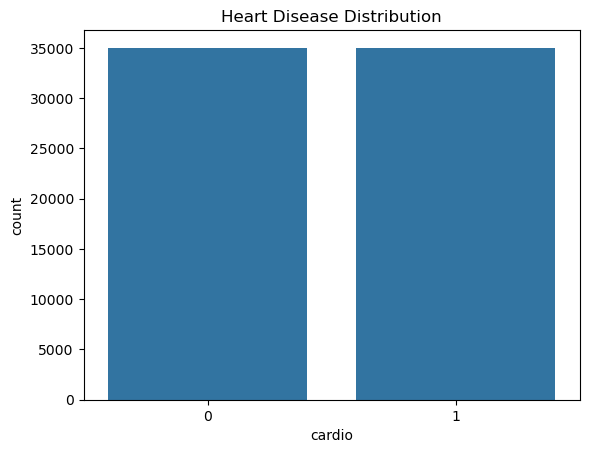

In [6]:
sns.countplot(x="cardio", data=df)
plt.title("Heart Disease Distribution")
plt.show()


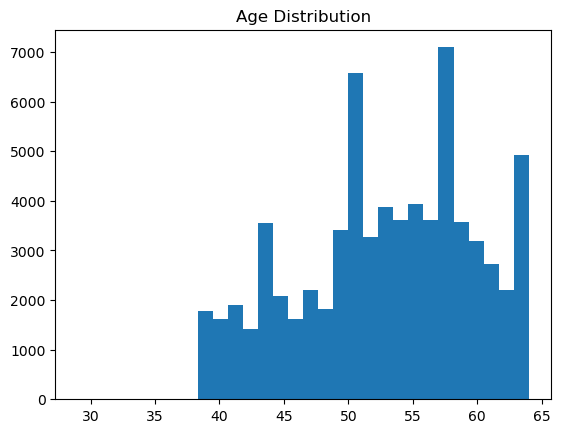

In [7]:
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.show()


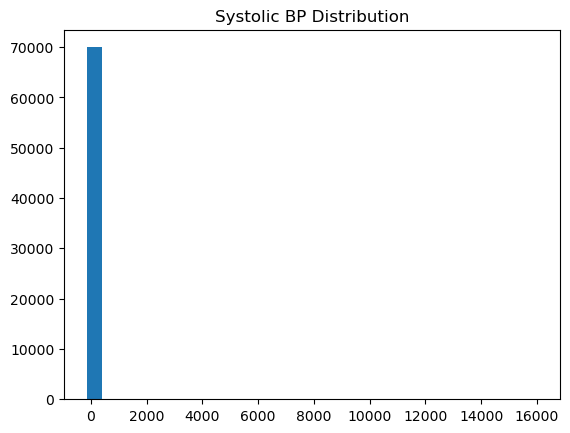

In [8]:
plt.hist(df["ap_hi"], bins=30)
plt.title("Systolic BP Distribution")
plt.show()


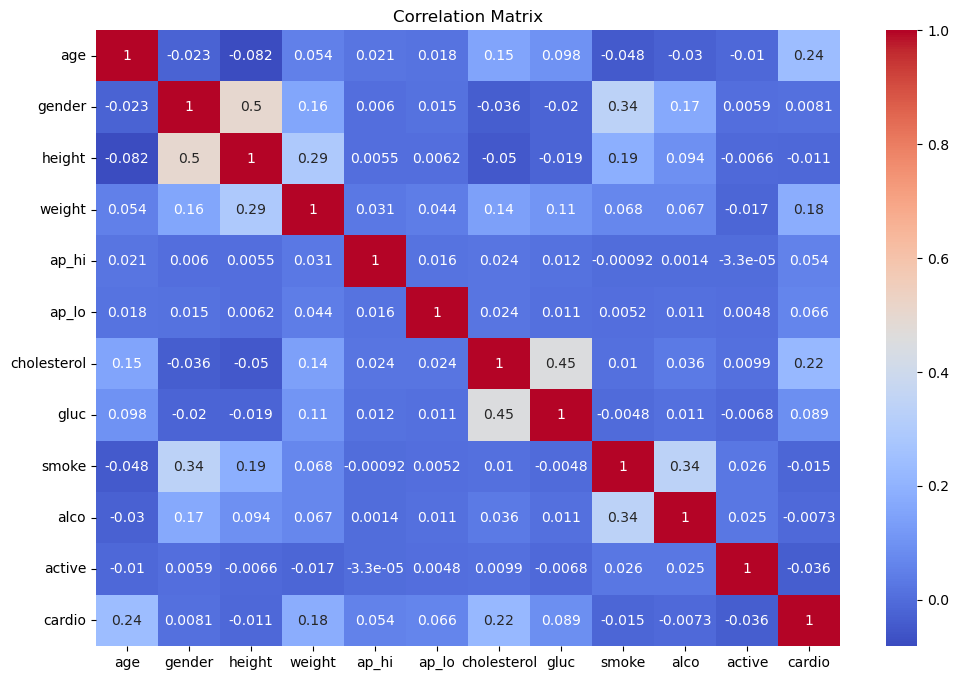

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [10]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)


Logistic Regression Accuracy: 0.7227142857142858


In [13]:
from sklearn.svm import LinearSVC

svm = LinearSVC(max_iter=5000)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.6566428571428572


In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)


KNN Accuracy: 0.6389285714285714


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.6342142857142857


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.7070714285714286


In [17]:
results = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_acc, svm_acc, knn_acc, dt_acc, rf_acc]
})

print(results)


             Algorithm  Accuracy
0  Logistic Regression  0.722714
1                  SVM  0.656643
2                  KNN  0.638929
3        Decision Tree  0.634214
4        Random Forest  0.707071


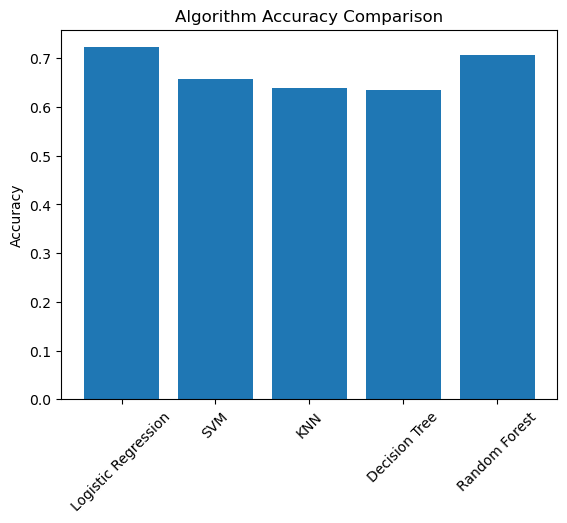

In [18]:
import matplotlib.pyplot as plt

plt.bar(results["Algorithm"], results["Accuracy"])
plt.xticks(rotation=45)
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
